## PubMedBert(Axis 1) + MLP(Axis 2)

In [1]:
!pip install python-dotenv

In [70]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
from pubmed_loader import PubMedQAData
from pubmedbert_preprocess import pubmedbert_preprocess

from evaluation_plot import evaluate, plot_confusion_matrix, get_error_samples, training_curves

# import matplotlib
# import os
# import shutil
# # Find the cache directory and delete it
# cache_dir = matplotlib.get_cachedir()
# if os.path.exists(cache_dir):
#     shutil.rmtree(cache_dir)
#     print(f"Cleared cache at {cache_dir}. Please restart your kernel!")

In [65]:
RANDOM_SEED = 11
MODEL_NAME  = "microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext"
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#DEVICE = torch.device("xpu" if torch.xpu.is_available() else "cpu")


def set_all_seeds(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"All seeds set to {seed}")

set_all_seeds()
print(f"Using device: {DEVICE}")

All seeds set to 11
Using device: cpu


In [66]:
LABEL_NAMES = {"yes": 0, "no": 1, "maybe": 2}
RANDOM_SEED = 11

### 1. Data loading

In [5]:
data = PubMedQAData("data")

# Variant A — plain question + context
train_enc_a, train_labels = pubmedbert_preprocess(data.train_set, tokenizer=AutoTokenizer.from_pretrained(MODEL_NAME), use_mesh=False)
dev_enc_a,   dev_labels   = pubmedbert_preprocess(data.dev_set,   tokenizer=AutoTokenizer.from_pretrained(MODEL_NAME), use_mesh=False)
test_enc_a,  test_labels  = pubmedbert_preprocess(data.test_set,  tokenizer=AutoTokenizer.from_pretrained(MODEL_NAME), use_mesh=False)

# Variant B — question + context + MeSH terms appended
tokenizer_b = AutoTokenizer.from_pretrained(MODEL_NAME)
train_enc_b, _            = pubmedbert_preprocess(data.train_set, tokenizer=tokenizer_b, use_mesh=True)
dev_enc_b,   _            = pubmedbert_preprocess(data.dev_set,   tokenizer=tokenizer_b, use_mesh=True)
test_enc_b,  _            = pubmedbert_preprocess(data.test_set,  tokenizer=tokenizer_b, use_mesh=True)

print(f"train: {len(train_labels)} | dev: {len(dev_labels)} | test: {len(test_labels)}")
print("Train label dist:", np.bincount(train_labels.numpy()))
print("Dev   label dist:", np.bincount(dev_labels.numpy()))
print("Test  label dist:", np.bincount(test_labels.numpy()))

train: 450 | dev: 50 | test: 500
Train label dist: [249 152  49]
Dev   label dist: [27 17  6]
Test  label dist: [276 169  55]


### 2. Class Weights
Inverse-frequency weighting so the loss penalises misclassifying `maybe` (≈11 %) much harder than `yes` (≈55 %).

In [6]:
counts        = np.bincount(train_labels.numpy())
counts_tensor = torch.FloatTensor(counts)
class_weights = 1.0 / counts_tensor
class_weights = class_weights / class_weights.sum() * 3   # normalise

print(f"Class counts : {counts}  (yes / no / maybe)")
print(f"Class weights: {class_weights.numpy().round(4)}")

Class counts : [249 152  49]  (yes / no / maybe)
Class weights: [0.3886 0.6366 1.9748]


### 3. Dataset — live tokenisation per batch

We switch from pre-cached embeddings to a **live Dataset** that feeds raw token IDs to a partially unfrozen BERT. This lets the top BERT layers adapt to the classification task, which is the main quality improvement.

In [7]:
# class EncodingDataset(Dataset):
#     """Thin wrapper around a tokenizer encoding dict + label tensor."""
#     def __init__(self, encodings, labels):
#         self.encodings = encodings
#         self.labels    = labels

#     def __len__(self):
#         return len(self.labels)

#     def __getitem__(self, idx):
#         return {
#             "input_ids":      self.encodings["input_ids"][idx],
#             "attention_mask": self.encodings["attention_mask"][idx],
#             "label":          self.labels[idx]
#         }

NameError: name 'Dataset' is not defined

### 2. Pre-compute `[CLS]` Embeddings
Because BERT is fully frozen, we run it **once** over every split and cache the `[CLS]` vectors.
All MLP training then operates on plain `(N, 768)` float tensors — no BERT forward pass per epoch.

In [7]:
def extract_cls_embeddings(encodings, model, device, batch_size=32):
    """
    Run frozen BERT once and return (N, 768) [CLS] embeddings.
    """
    model.eval()
    all_cls = []
    n = encodings["input_ids"].size(0)

    with torch.no_grad():
        for start in range(0, n, batch_size):
            end       = min(start + batch_size, n)
            input_ids = encodings["input_ids"][start:end].to(device)
            attn_mask = encodings["attention_mask"][start:end].to(device)
            outputs   = model(input_ids=input_ids, attention_mask=attn_mask)
            cls_vec   = outputs.last_hidden_state[:, 0, :].cpu()
            all_cls.append(cls_vec)

    return torch.cat(all_cls, dim=0)   # (N, 768)


bert_model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
for p in bert_model.parameters():
    p.requires_grad = False
print("BERT loaded and frozen.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT loaded and frozen.


In [8]:
# ── Variant A ──────────────────────────────────────────────────────────────
print("Extracting Variant A embeddings (plain)...")
train_emb_a = extract_cls_embeddings(train_enc_a, bert_model, DEVICE)
dev_emb_a   = extract_cls_embeddings(dev_enc_a,   bert_model, DEVICE)
test_emb_a  = extract_cls_embeddings(test_enc_a,  bert_model, DEVICE)
print(f"  train {train_emb_a.shape} | dev {dev_emb_a.shape} | test {test_emb_a.shape}")

# ── Variant B ──────────────────────────────────────────────────────────────
print("Extracting Variant B embeddings (+ MeSH)...")
train_emb_b = extract_cls_embeddings(train_enc_b, bert_model, DEVICE)
dev_emb_b   = extract_cls_embeddings(dev_enc_b,   bert_model, DEVICE)
test_emb_b  = extract_cls_embeddings(test_enc_b,  bert_model, DEVICE)
print(f"  train {train_emb_b.shape} | dev {dev_emb_b.shape} | test {test_emb_b.shape}")

print("\nDone. BERT will not run again during MLP training.")

Extracting Variant A embeddings (plain)...
  train torch.Size([450, 768]) | dev torch.Size([50, 768]) | test torch.Size([500, 768])
Extracting Variant B embeddings (+ MeSH)...
  train torch.Size([450, 768]) | dev torch.Size([50, 768]) | test torch.Size([500, 768])

Done. BERT will not run again during MLP training.


### 4. DataLoaders

In [9]:
BATCH_SIZE = 64

def make_loaders(train_emb, dev_emb, test_emb,
                 train_labels, dev_labels, test_labels,
                 batch_size=BATCH_SIZE):
    train_ds     = TensorDataset(train_emb, train_labels)
    dev_ds       = TensorDataset(dev_emb,   dev_labels)
    test_ds      = TensorDataset(test_emb,  test_labels)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    dev_loader   = DataLoader(dev_ds,   batch_size=batch_size)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size)
    return train_loader, dev_loader, test_loader

train_loader_a, dev_loader_a, test_loader_a = make_loaders(
    train_emb_a, dev_emb_a, test_emb_a,
    train_labels, dev_labels, test_labels
)
train_loader_b, dev_loader_b, test_loader_b = make_loaders(
    train_emb_b, dev_emb_b, test_emb_b,
    train_labels, dev_labels, test_labels
)
print("DataLoaders ready.")

DataLoaders ready.


### 5. MLP Architecture (wider + BatchNorm)

In [10]:
class MLP(nn.Module):
    """Wider MLP on pre-computed 768-dim [CLS] vectors.
    768 -> 512 -> 128 -> 3 with BatchNorm for stable training.
    """
    def __init__(self, input_dim=768):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 3)
        )

    def forward(self, x):
        return self.network(x)

### 6. Training Loop (class weights + cosine scheduler)

In [11]:
def train_MLP(num_epochs, model, train_loader, dev_loader,
              learning_rate, class_weights=None):

    loss_fn = nn.CrossEntropyLoss(
        weight=class_weights.to(next(model.parameters()).device)
        if class_weights is not None else None
    )
    if class_weights is not None:
        print(f"Using Weighted CrossEntropy: {class_weights.numpy().round(4)}")

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    all_train_losses = []
    all_dev_losses   = []
    best_dev_loss    = float('inf')
    best_state       = None

    for e in range(num_epochs):
        # ── Training ────────────────────────────────────────────────────────
        model.train()
        train_losses  = []
        total_correct = 0
        total_trained = 0

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(DEVICE), batch_y.to(DEVICE)
            optimizer.zero_grad()
            output     = model(batch_X)
            batch_loss = loss_fn(output, batch_y)
            batch_loss.backward()
            optimizer.step()

            train_losses.append(batch_loss.item())
            total_correct += (output.argmax(1) == batch_y).sum().item()
            total_trained += batch_y.size(0)

        scheduler.step()
        train_acc = total_correct / total_trained * 100
        all_train_losses.append(np.mean(train_losses))
        print("Epoch: {}/{}".format(e + 1, num_epochs),
              "Training Loss: {:.4f}".format(np.mean(train_losses)),
              "Training Accuracy: {:.4f}%".format(train_acc))

        # ── Validation ──────────────────────────────────────────────────────
        model.eval()
        dev_losses    = []
        total_correct = 0
        total_trained = 0

        with torch.no_grad():
            for dev_X, dev_y in dev_loader:
                dev_X, dev_y = dev_X.to(DEVICE), dev_y.to(DEVICE)
                dev_output   = model(dev_X)
                dev_loss     = loss_fn(dev_output, dev_y)
                dev_losses.append(dev_loss.item())
                total_correct += (dev_output.argmax(1) == dev_y).sum().item()
                total_trained += dev_y.size(0)

        dev_acc       = total_correct / total_trained * 100
        mean_dev_loss = np.mean(dev_losses)
        all_dev_losses.append(mean_dev_loss)
        print("Epoch: {}/{}".format(e + 1, num_epochs),
              "Validation Loss: {:.4f}".format(mean_dev_loss),
              "Validation Accuracy: {:.4f}%".format(dev_acc))

        if mean_dev_loss < best_dev_loss:
            best_dev_loss = mean_dev_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            print(f"Best model saved (validation_loss={best_dev_loss:.4f})")

    model.load_state_dict(best_state)
    print(f"Restored best model (validation_loss={best_dev_loss:.4f})")
    return model, all_train_losses, all_dev_losses

### 7. Evaluation Utilities

In [12]:
def training_curves(train_losses, dev_losses, title="Training curves"):
    plt.figure()
    plt.plot(train_losses, label="Training Loss")
    plt.plot(dev_losses,   label="Validation Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()


def predict(model, loader):
    model.eval()
    gold_labs, pred_labs = [], []
    with torch.no_grad():
        for X, y in loader:
            X                = X.to(DEVICE)
            predicted_labels = model(X).argmax(1)
            gold_labs.extend(y.tolist())
            pred_labs.extend(predicted_labels.cpu().tolist())
    return gold_labs, pred_labs


def evaluate(y_pred, y_true, split_name):
    acc       = accuracy_score(y_true, y_pred)
    f1_macro  = f1_score(y_true, y_pred, average="macro")
    pre_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
    print(f"\n── {split_name} ──")
    print(f"Accuracy       : {acc:.4f}")
    print(f"Macro-F1       : {f1_macro:.4f}")
    print(f"Macro-Precision: {pre_macro:.4f}")
    print("\nFull Classification Report:")
    print(classification_report(y_true, y_pred,
                                target_names=["yes", "no", "maybe"],
                                zero_division=0))
    return acc, f1_macro, pre_macro


def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=["yes", "no", "maybe"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title); plt.tight_layout(); plt.show()

---
## Axis 1 — Text Representation

| | Input to BERT |
|---|---|
| **Variant A** | `[question] + [context]` (plain baseline) |
| **Variant B** | `[question] + [context] + MeSH terms` (enriched) |

**Hypothesis:** MeSH terms are controlled biomedical vocabulary. Appending them may sharpen the `[CLS]` embedding for domain-specific topics, especially helping the minority `maybe` class. However, MeSH terms appear at the end of the 512-token window so if a context is already long they may get truncated — an important failure mode to check in error analysis.

---
### Variant A — Plain question + context

In [33]:
set_all_seeds()

num_epochs    = 20
learning_rate = 0.001

model_a = MLP(input_dim=768).to(DEVICE)
trained_model_a, train_losses_a, dev_losses_a = train_MLP(
    num_epochs, model_a, train_loader_a, dev_loader_a, learning_rate, class_weights=class_weights
)

All seeds set to 11
Using Weighted CrossEntropy: [0.3886 0.6366 1.9748]
Epoch: 1/20 Training Loss: 1.2213 Training Accuracy: 34.8889%
Epoch: 1/20 Validation Loss: 1.0909 Validation Accuracy: 14.0000%
Best model saved (validation_loss=1.0909)
Epoch: 2/20 Training Loss: 0.8667 Training Accuracy: 56.2222%
Epoch: 2/20 Validation Loss: 1.0741 Validation Accuracy: 18.0000%
Best model saved (validation_loss=1.0741)
Epoch: 3/20 Training Loss: 0.7180 Training Accuracy: 65.7778%
Epoch: 3/20 Validation Loss: 1.0679 Validation Accuracy: 22.0000%
Best model saved (validation_loss=1.0679)
Epoch: 4/20 Training Loss: 0.6053 Training Accuracy: 74.4444%
Epoch: 4/20 Validation Loss: 1.0402 Validation Accuracy: 36.0000%
Best model saved (validation_loss=1.0402)
Epoch: 5/20 Training Loss: 0.5196 Training Accuracy: 83.5556%
Epoch: 5/20 Validation Loss: 1.0247 Validation Accuracy: 50.0000%
Best model saved (validation_loss=1.0247)
Epoch: 6/20 Training Loss: 0.4645 Training Accuracy: 87.5556%
Epoch: 6/20 Vali

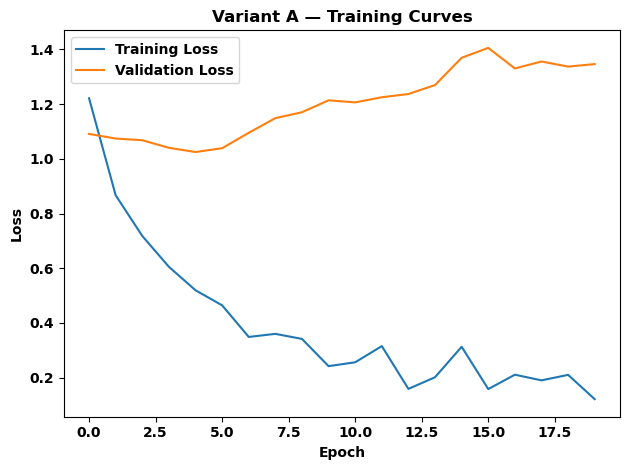

In [34]:
training_curves(train_losses_a, dev_losses_a, title="Variant A — Training Curves")

In [35]:
y_true_a, y_pred_a = predict(trained_model_a, test_loader_a)
acc_a, f1_a, pre_a = evaluate(y_pred_a, y_true_a, "Variant A — Test (plain)")


── Variant A — Test (plain) ──
Accuracy       : 0.4260
Macro-F1       : 0.3856
Macro-Precision: 0.4209

Full Classification Report:
              precision    recall  f1-score   support

         yes       0.68      0.42      0.52       276
          no       0.46      0.46      0.46       169
       maybe       0.12      0.35      0.18        55

    accuracy                           0.43       500
   macro avg       0.42      0.41      0.39       500
weighted avg       0.55      0.43      0.46       500



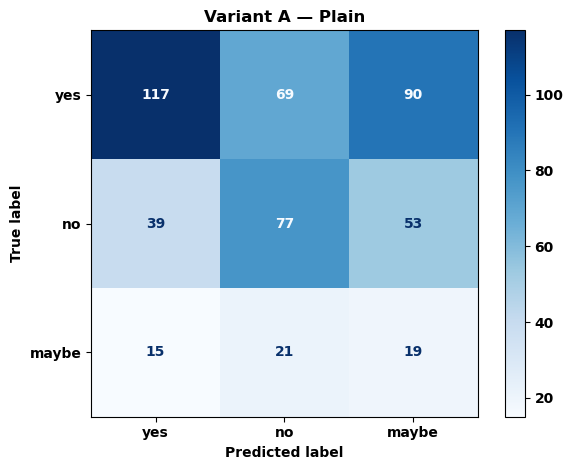

In [36]:
plot_confusion_matrix(y_true_a, y_pred_a, title="Variant A — Plain")

---
### Variant B — Question + context + MeSH (enriched representation)

In [37]:
set_all_seeds()

model_b = MLP(input_dim=768).to(DEVICE)
trained_model_b, train_losses_b, dev_losses_b = train_MLP(
    num_epochs, model_b, train_loader_b, dev_loader_b, learning_rate, class_weights=class_weights
)

All seeds set to 11
Using Weighted CrossEntropy: [0.3886 0.6366 1.9748]
Epoch: 1/20 Training Loss: 1.2775 Training Accuracy: 29.7778%
Epoch: 1/20 Validation Loss: 1.0925 Validation Accuracy: 14.0000%
Best model saved (validation_loss=1.0925)
Epoch: 2/20 Training Loss: 0.9600 Training Accuracy: 54.4444%
Epoch: 2/20 Validation Loss: 1.0790 Validation Accuracy: 18.0000%
Best model saved (validation_loss=1.0790)
Epoch: 3/20 Training Loss: 0.7863 Training Accuracy: 58.0000%
Epoch: 3/20 Validation Loss: 1.0571 Validation Accuracy: 26.0000%
Best model saved (validation_loss=1.0571)
Epoch: 4/20 Training Loss: 0.6460 Training Accuracy: 70.8889%
Epoch: 4/20 Validation Loss: 1.0311 Validation Accuracy: 38.0000%
Best model saved (validation_loss=1.0311)
Epoch: 5/20 Training Loss: 0.6083 Training Accuracy: 78.0000%
Epoch: 5/20 Validation Loss: 1.0129 Validation Accuracy: 50.0000%
Best model saved (validation_loss=1.0129)
Epoch: 6/20 Training Loss: 0.5081 Training Accuracy: 84.2222%
Epoch: 6/20 Vali

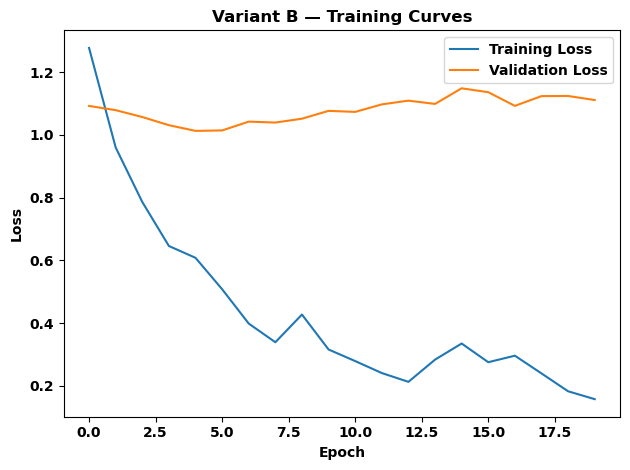

In [38]:
training_curves(train_losses_b, dev_losses_b, title="Variant B — Training Curves")

In [39]:
y_true_b, y_pred_b = predict(trained_model_b, test_loader_b)
acc_b, f1_b, pre_b = evaluate(y_pred_b, y_true_b, "Variant B — Test (+ MeSH)")


── Variant B — Test (+ MeSH) ──
Accuracy       : 0.4460
Macro-F1       : 0.3906
Macro-Precision: 0.3956

Full Classification Report:
              precision    recall  f1-score   support

         yes       0.61      0.51      0.55       276
          no       0.41      0.38      0.39       169
       maybe       0.17      0.35      0.22        55

    accuracy                           0.45       500
   macro avg       0.40      0.41      0.39       500
weighted avg       0.49      0.45      0.46       500



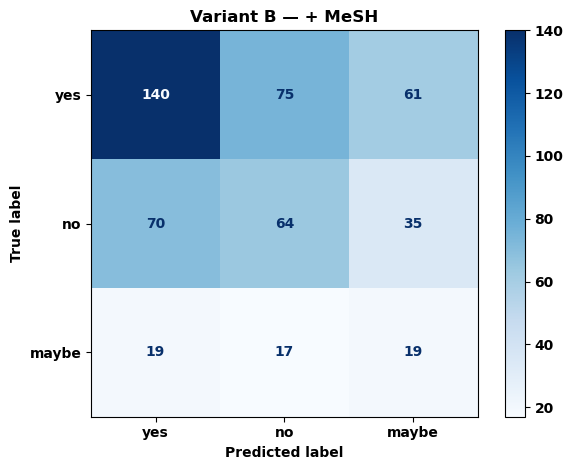

In [40]:
plot_confusion_matrix(y_true_b, y_pred_b, title="Variant B — + MeSH")

---
## Summary: Variant A vs. Variant B

In [41]:
print(f"{'Variant':<40} {'Accuracy':>10} {'Macro-F1':>10} {'Macro-Prec':>12}")
print("-" * 75)
for name, acc, f1, pre in [
    ("Variant A  — Plain (question + context)",  acc_a, f1_a, pre_a),
    ("Variant B  — Enriched (+ MeSH terms)",     acc_b, f1_b, pre_b),
]:
    print(f"{name:<40} {acc:>10.4f} {f1:>10.4f} {pre:>12.4f}")

Variant                                    Accuracy   Macro-F1   Macro-Prec
---------------------------------------------------------------------------
Variant A  — Plain (question + context)      0.4260     0.3856       0.4209
Variant B  — Enriched (+ MeSH terms)         0.4460     0.3906       0.3956


---
## Side-by-side Confusion Matrices

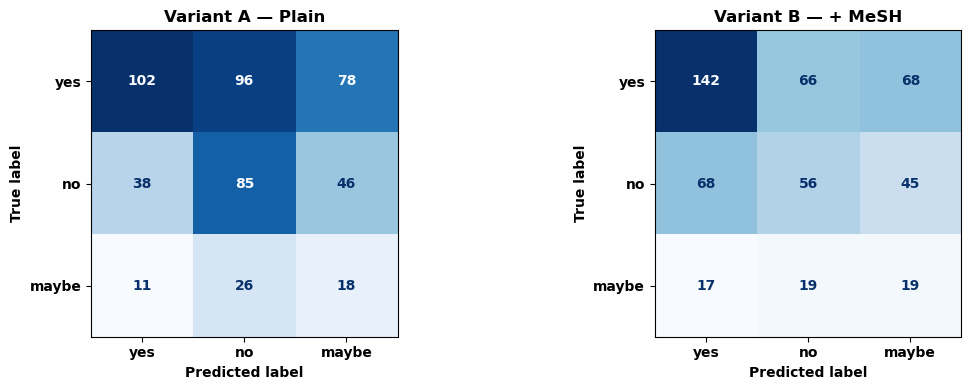

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_true, y_pred, title in [
    (axes[0], y_true_a, y_pred_a, "Variant A — Plain"),
    (axes[1], y_true_b, y_pred_b, "Variant B — + MeSH"),
]:
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["yes", "no", "maybe"]
    )
    disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [69]:
%run evaluation_plot.py


---
## Improved Training: Class Weighting + Early Stopping

Adapted from the BioWordVec pipeline. Both techniques address specific weaknesses:
- **Class weighting** penalises misclassification of the rare *maybe* class more heavily.
- **Early stopping** prevents over-fitting when BERT embeddings provide a rich but fixed feature space.

In [51]:
# ── Compute inverse-frequency class weights ──────────────────────────────
counts        = np.bincount(train_labels.numpy())
counts_tensor = torch.FloatTensor(counts)
class_weights = 1.0 / counts_tensor
class_weights = class_weights / class_weights.sum() * 3   # normalise to n_classes
print(f"Label counts  : {counts}")
print(f"Class weights : {class_weights}")


def train_MLP_es(num_epochs, model, train_loader, dev_loader,
                 learning_rate, class_weights=None, patience=5):
    """train_MLP with early stopping support."""
    if class_weights is not None:
        loss_fn = nn.CrossEntropyLoss(
            weight=class_weights.to(next(model.parameters()).device)
        )
        print(f"Using Weighted CrossEntropy: {class_weights}")
    else:
        loss_fn = nn.CrossEntropyLoss()

    optimizer        = optim.Adam(model.parameters(), lr=learning_rate)
    all_train_losses = []
    all_dev_losses   = []
    best_dev_loss    = float('inf')
    best_state       = None
    patience_counter = 0

    for e in range(num_epochs):
        model.train()
        train_losses, correct, total = [], 0, 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(DEVICE), batch_y.to(DEVICE)
            optimizer.zero_grad()
            output     = model(batch_X)
            batch_loss = loss_fn(output, batch_y)
            batch_loss.backward()
            optimizer.step()
            train_losses.append(batch_loss.item())
            correct += (output.argmax(1) == batch_y).sum().item()
            total   += batch_y.size(0)

        train_acc = correct / total * 100
        mean_train = np.mean(train_losses)
        all_train_losses.append(mean_train)

        model.eval()
        dev_losses, correct, total = [], 0, 0
        with torch.no_grad():
            for dev_X, dev_y in dev_loader:
                dev_X, dev_y = dev_X.to(DEVICE), dev_y.to(DEVICE)
                dev_out      = model(dev_X)
                dev_losses.append(loss_fn(dev_out, dev_y).item())
                correct += (dev_out.argmax(1) == dev_y).sum().item()
                total   += dev_y.size(0)

        dev_acc    = correct / total * 100
        mean_dev   = np.mean(dev_losses)
        all_dev_losses.append(mean_dev)
        print(f"Epoch {e+1}/{num_epochs}  Train {mean_train:.4f}/{train_acc:.1f}%  "
              f"Val {mean_dev:.4f}/{dev_acc:.1f}%")

        if mean_dev < best_dev_loss:
            best_dev_loss    = mean_dev
            best_state       = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            print(f"  ✓ Best model saved (val_loss={best_dev_loss:.4f})")
        else:
            patience_counter += 1
            print(f"  No improvement. Patience {patience_counter}/{patience}")
            if patience_counter >= patience:
                print(f"Early stopping at epoch {e+1}")
                break

    model.load_state_dict(best_state)
    print(f"Restored best model (val_loss={best_dev_loss:.4f})")
    return model, all_train_losses, all_dev_losses

Label counts  : [249 152  49]
Class weights : tensor([0.3886, 0.6366, 1.9748])


All seeds set to 11
Using Weighted CrossEntropy: tensor([0.3886, 0.6366, 1.9748])
Epoch 1/50  Train 1.2166/32.7%  Val 1.0929/12.0%
  ✓ Best model saved (val_loss=1.0929)
Epoch 2/50  Train 0.9125/56.4%  Val 1.0822/12.0%
  ✓ Best model saved (val_loss=1.0822)
Epoch 3/50  Train 0.7733/65.1%  Val 1.0701/16.0%
  ✓ Best model saved (val_loss=1.0701)
Epoch 4/50  Train 0.6870/71.3%  Val 1.0526/24.0%
  ✓ Best model saved (val_loss=1.0526)
Epoch 5/50  Train 0.6295/77.3%  Val 1.0298/42.0%
  ✓ Best model saved (val_loss=1.0298)
Epoch 6/50  Train 0.5620/81.3%  Val 1.0318/50.0%
  No improvement. Patience 1/7
Epoch 7/50  Train 0.4603/86.9%  Val 1.0494/52.0%
  No improvement. Patience 2/7
Epoch 8/50  Train 0.4701/91.3%  Val 1.0628/52.0%
  No improvement. Patience 3/7
Epoch 9/50  Train 0.4684/91.3%  Val 1.0815/54.0%
  No improvement. Patience 4/7
Epoch 10/50  Train 0.3177/93.6%  Val 1.0757/52.0%
  No improvement. Patience 5/7
Epoch 11/50  Train 0.3232/92.7%  Val 1.0866/50.0%
  No improvement. Patience 

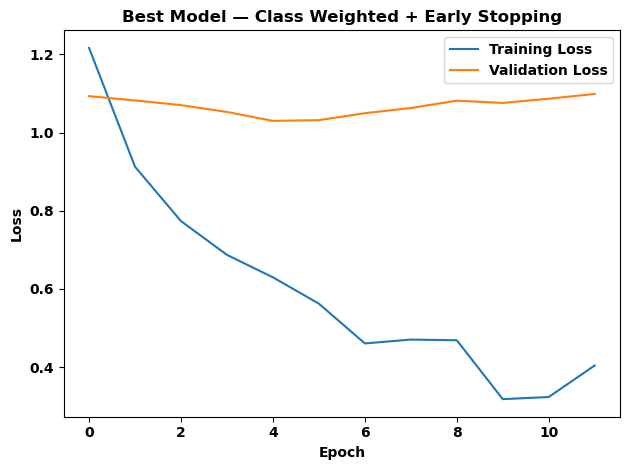


── Best Model — Weighted + ES ──
Accuracy       : 0.3820
Macro-F1       : 0.3581
Macro-Precision: 0.4133

Full Classification Report:
              precision    recall  f1-score   support

         yes       0.70      0.35      0.46       276
          no       0.42      0.43      0.42       169
       maybe       0.12      0.42      0.19        55

    accuracy                           0.38       500
   macro avg       0.41      0.40      0.36       500
weighted avg       0.54      0.38      0.42       500



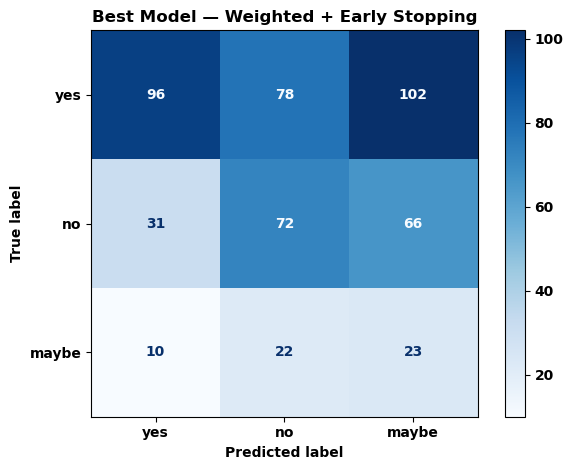

In [52]:
# Best architecture with class weighting + early stopping
set_all_seeds()
model_best = MLP(input_dim=768).to(DEVICE)
trained_best, train_losses_best, dev_losses_best = train_MLP_es(
    num_epochs=50,
    model=model_best,
    train_loader=BEST_TRAIN_LOADER,
    dev_loader=BEST_DEV_LOADER,
    learning_rate=0.0005,
    class_weights=class_weights,
    patience=7
)
training_curves(train_losses_best, dev_losses_best, title="Best Model — Class Weighted + Early Stopping")
y_true_best, y_pred_best = predict(trained_best, BEST_TEST_LOADER)
acc_best, f1_best, pre_best = evaluate(y_pred_best, y_true_best, "Best Model — Weighted + ES")
plot_confusion_matrix(y_true_best, y_pred_best, title="Best Model — Weighted + Early Stopping")

---
## Error Analysis

We investigate two main failure hypotheses:
1. **MeSH truncation** — for Variant B, do errors correlate with longer contexts (where MeSH terms get cut off)?
2. **Question ambiguity** — do misclassified samples tend to have shorter or longer questions?
3. **Class confusion pattern** — are errors concentrated on the *maybe* class?

In [53]:
# ── Build a rich error dataframe ────────────────────────────────────────────
import pandas as pd

LABEL_INV = {0: "yes", 1: "no", 2: "maybe"}

test_items = list(data.test_set.items())

def build_error_df(y_true, y_pred, label="model"):
    rows = []
    for i, (pmid, sample) in enumerate(test_items):
        question    = sample["QUESTION"]
        context_len = sum(len(c) for c in sample["CONTEXTS"])
        mesh_terms  = sample.get("MESHES", [])
        rows.append({
            "pmid"        : pmid,
            "question"    : question,
            "q_len"       : len(question.split()),
            "context_len" : context_len,
            "n_mesh"      : len(mesh_terms),
            "true"        : LABEL_INV[y_true[i]],
            "pred"        : LABEL_INV[y_pred[i]],
            "correct"     : y_true[i] == y_pred[i],
            "label"       : label,
        })
    return pd.DataFrame(rows)

df_a    = build_error_df(y_true_a,    y_pred_a,    label="Variant A")
df_b    = build_error_df(y_true_b,    y_pred_b,    label="Variant B")
df_best = build_error_df(y_true_best, y_pred_best, label="Best Model")

print(f"Variant A  — Total errors: {(~df_a['correct']).sum()} / {len(df_a)}")
print(f"Variant B  — Total errors: {(~df_b['correct']).sum()} / {len(df_b)}")
print(f"Best Model — Total errors: {(~df_best['correct']).sum()} / {len(df_best)}")

Variant A  — Total errors: 287 / 500
Variant B  — Total errors: 277 / 500
Best Model — Total errors: 309 / 500


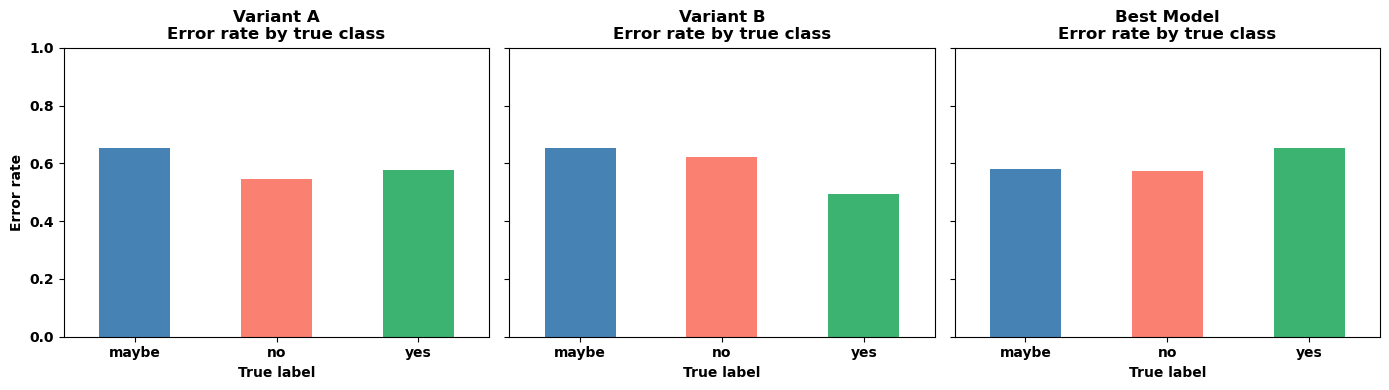

In [54]:
# ── 1. Error rate by true class ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, df, title in [
    (axes[0], df_a,    "Variant A"),
    (axes[1], df_b,    "Variant B"),
    (axes[2], df_best, "Best Model"),
]:
    err_by_class = df.groupby("true")["correct"].apply(lambda x: (~x).mean())
    err_by_class.plot(kind="bar", ax=ax, color=["steelblue", "salmon", "mediumseagreen"])
    ax.set_title(f"{title}\nError rate by true class")
    ax.set_ylabel("Error rate")
    ax.set_xlabel("True label")
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

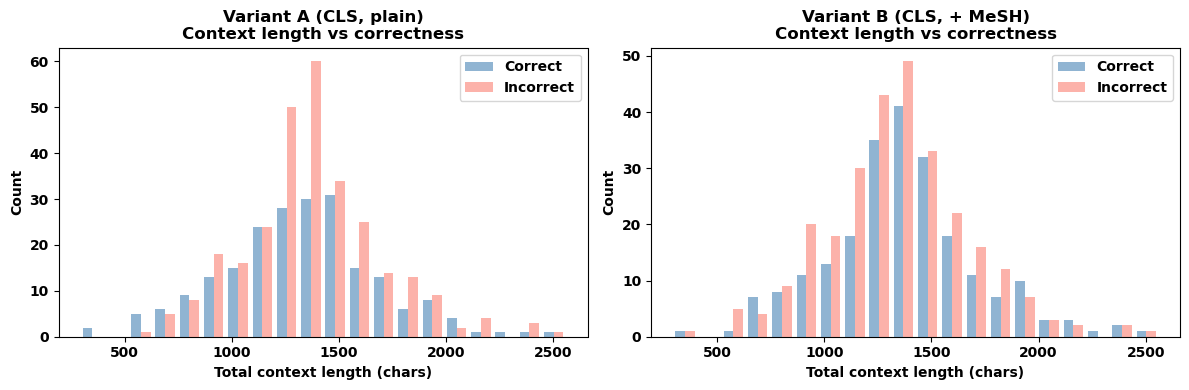

Variant B — t-test context length (correct vs incorrect):
  Mean correct context len   : 1371 chars
  Mean incorrect context len : 1333 chars
  t=1.249, p=0.2121
  → MeSH truncation hypothesis NOT supported at p<0.05


In [55]:
# ── 2. Context length vs correctness ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df, title in [
    (axes[0], df_a, "Variant A (CLS, plain)"),
    (axes[1], df_b, "Variant B (CLS, + MeSH)"),
]:
    correct_ctx   = df[df["correct"]  ]["context_len"]
    incorrect_ctx = df[~df["correct"] ]["context_len"]
    ax.hist([correct_ctx, incorrect_ctx], bins=20, label=["Correct", "Incorrect"],
            alpha=0.6, color=["steelblue", "salmon"])
    ax.set_title(f"{title}\nContext length vs correctness")
    ax.set_xlabel("Total context length (chars)")
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()

# Statistical test: are long-context samples harder for Variant B (MeSH truncation)?
from scipy import stats
correct_b   = df_b[df_b["correct"]]["context_len"]
incorrect_b = df_b[~df_b["correct"]]["context_len"]
t_stat, p_val = stats.ttest_ind(correct_b, incorrect_b)
print(f"Variant B — t-test context length (correct vs incorrect):")
print(f"  Mean correct context len   : {correct_b.mean():.0f} chars")
print(f"  Mean incorrect context len : {incorrect_b.mean():.0f} chars")
print(f"  t={t_stat:.3f}, p={p_val:.4f}")
print("  → MeSH truncation hypothesis", "SUPPORTED" if p_val < 0.05 else "NOT supported", "at p<0.05")

C:\Users\User\AppData\Local\Temp\ipykernel_58624\874786129.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


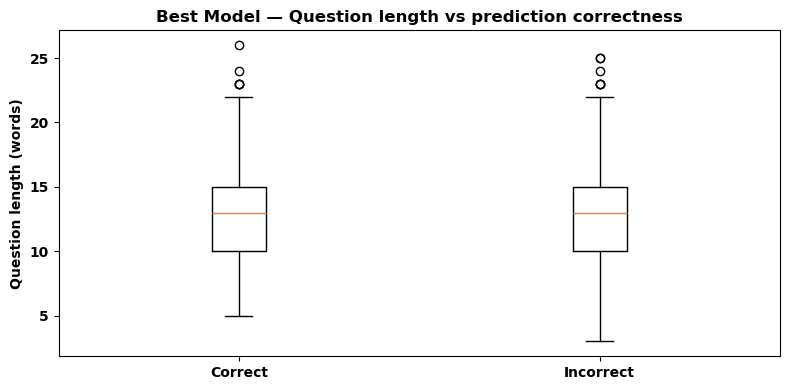

t=0.310, p=0.7567


In [56]:
# ── 3. Question length vs correctness ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(
    [df_best[df_best["correct"]]["q_len"],
     df_best[~df_best["correct"]]["q_len"]],
    labels=["Correct", "Incorrect"]
)
ax.set_title("Best Model — Question length vs prediction correctness")
ax.set_ylabel("Question length (words)")
plt.tight_layout()
plt.show()

t2, p2 = stats.ttest_ind(
    df_best[df_best["correct"]]["q_len"],
    df_best[~df_best["correct"]]["q_len"]
)
print(f"t={t2:.3f}, p={p2:.4f}")

In [57]:
# ── 4. Print top-10 worst errors (qualitative) ───────────────────────────────
errors = df_best[~df_best["correct"]].sort_values("context_len", ascending=False)
print("Top 10 errors (longest context first):\n")
for _, row in errors.head(10).iterrows():
    print(f"PMID       : {row['pmid']}")
    print(f"Question   : {row['question']}")
    print(f"True → Pred: {row['true']} → {row['pred']}")
    print(f"Context len: {row['context_len']} chars | Q len: {row['q_len']} words")
    print("-" * 70)

Top 10 errors (longest context first):

PMID       : 22382608
Question   : SPECT study with I-123-Ioflupane (DaTSCAN) in patients with essential tremor. Is there any correlation with Parkinson's disease?
True → Pred: no → yes
Context len: 2559 chars | Q len: 17 words
----------------------------------------------------------------------
PMID       : 27549226
Question   : Impact of MPH programs: contributing to health system strengthening in low- and middle-income countries?
True → Pred: yes → maybe
Context len: 2411 chars | Q len: 14 words
----------------------------------------------------------------------
PMID       : 9542484
Question   : Does successful completion of the Perinatal Education Programme result in improved obstetric practice?
True → Pred: no → maybe
Context len: 2393 chars | Q len: 13 words
----------------------------------------------------------------------
PMID       : 25940336
Question   : Does Residency Selection Criteria Predict Performance in Orthopaedic Surge

---
## Task 3 — Predicting Answer Quality from Question Characteristics

**Goal:** Can we predict, from features of the *question alone*, whether the model is likely to answer correctly?

We train a small regressor/classifier on question-level features to predict the binary `correct/incorrect` outcome of the best model. Features are entirely derived from the question text — no context or labels are used.

**Features extracted from each question:**
- Question length (words)
- Number of question marks (malformed questions may appear)
- Presence of hedging words (*whether*, *if*, *can*, *may*)
- Presence of comparison words (*compared*, *versus*, *vs*, *difference*)
- Number of medical acronyms (uppercase tokens ≥ 2 chars)
- PubMedBERT `[CLS]` embedding of the question only (768 dims)

We compare a **logistic regression** baseline vs a **small neural network**.

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import re

HEDGE_WORDS   = {"whether", "if", "can", "may", "might", "could", "possibly",
                 "potential", "potentially", "suggest", "suggest", "risk"}
COMPARE_WORDS = {"compared", "comparison", "versus", "vs", "difference",
                 "differences", "better", "superior", "worse", "effect"}

def handcraft_features(question):
    tokens = question.lower().split()
    raw    = question.split()
    feats  = [
        len(tokens),                                                          # q length
        question.count("?"),                                                  # n question marks
        int(any(t in HEDGE_WORDS   for t in tokens)),                        # hedging flag
        int(any(t in COMPARE_WORDS for t in tokens)),                        # comparison flag
        sum(1 for t in raw if re.fullmatch(r"[A-Z]{2,}", t)),                # medical acronyms
        len([t for t in tokens if t.isalpha()]) / max(len(tokens), 1),       # alpha token ratio
    ]
    return feats

print("Sample features for first test question:")
sample_q = test_items[0][1]["QUESTION"]
print(f"  Q: {sample_q}")
print(f"  Features: {handcraft_features(sample_q)}")

Sample features for first test question:
  Q: Is anorectal endosonography valuable in dyschesia?
  Features: [6, 1, 0, 0, 0, 0.8333333333333334]


In [59]:
# ── Build feature matrices ───────────────────────────────────────────────────

def build_quality_dataset(items, y_correct, bert_model, tokenizer, device, batch_size=32):
    """
    Returns:
      X_hand  : (N, 6)  hand-crafted question features
      X_bert  : (N, 768) BERT [CLS] of question only
      y       : (N,) binary correct/incorrect
    """
    questions = [sample["QUESTION"] for _, sample in items]
    y         = np.array(y_correct, dtype=np.float32)

    # Hand-crafted
    X_hand = np.array([handcraft_features(q) for q in questions], dtype=np.float32)

    # BERT [CLS] — question only
    tokenizer_q = tokenizer
    enc = tokenizer_q(
        questions,
        padding="max_length",
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )
    X_bert = extract_cls_embeddings(enc, bert_model, device, batch_size=batch_size).numpy()

    return X_hand, X_bert, y


tokenizer_q = AutoTokenizer.from_pretrained(MODEL_NAME)

# Build train / test sets for quality prediction
train_items_q = list(data.train_set.items())

# Predict train correctness using best model on train split
y_true_train, y_pred_train = predict(trained_best,
    DataLoader(TensorDataset(train_emb_a, train_labels), batch_size=64))
y_correct_train = [int(t == p) for t, p in zip(y_true_train, y_pred_train)]
y_correct_test  = [int(t == p) for t, p in zip(y_true_best,  y_pred_best)]

print("Building quality prediction features...")
X_hand_tr, X_bert_tr, y_q_tr = build_quality_dataset(
    train_items_q, y_correct_train, bert_model, tokenizer_q, DEVICE)
X_hand_te, X_bert_te, y_q_te = build_quality_dataset(
    test_items, y_correct_test, bert_model, tokenizer_q, DEVICE)
print(f"Train: {X_hand_tr.shape}  |  Test: {X_hand_te.shape}")
print(f"Train correctness rate: {y_q_tr.mean():.2%}  Test: {y_q_te.mean():.2%}")

Building quality prediction features...
Train: (450, 6)  |  Test: (500, 6)
Train correctness rate: 77.56%  Test: 38.20%


In [60]:
from sklearn.metrics import roc_auc_score

# ── Baseline: Logistic Regression on hand-crafted features ─────────────────
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr",     LogisticRegression(max_iter=1000, class_weight="balanced"))
])
lr_pipe.fit(X_hand_tr, y_q_tr)
y_hat_lr = lr_pipe.predict(X_hand_te)
lr_acc   = accuracy_score(y_q_te, y_hat_lr)
lr_auc   = roc_auc_score(y_q_te, lr_pipe.predict_proba(X_hand_te)[:, 1])
print(f"Logistic Regression (hand features): Acc={lr_acc:.4f}  AUC={lr_auc:.4f}")

# Feature importances (via LR coefficients)
feat_names = ["q_len", "n_q_marks", "hedge", "compare", "acronyms", "alpha_ratio"]
coefs      = lr_pipe.named_steps["lr"].coef_[0]
print("\nLR coefficients (positive = predicts correct):")
for name, coef in sorted(zip(feat_names, coefs), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {name:<15}: {coef:+.4f}")

Logistic Regression (hand features): Acc=0.4740  AUC=0.4582

LR coefficients (positive = predicts correct):
  hedge          : -0.0635
  q_len          : +0.0509
  alpha_ratio    : -0.0204
  compare        : +0.0170
  acronyms       : +0.0149
  n_q_marks      : +0.0000


All seeds set to 11
Early stopping at epoch 21


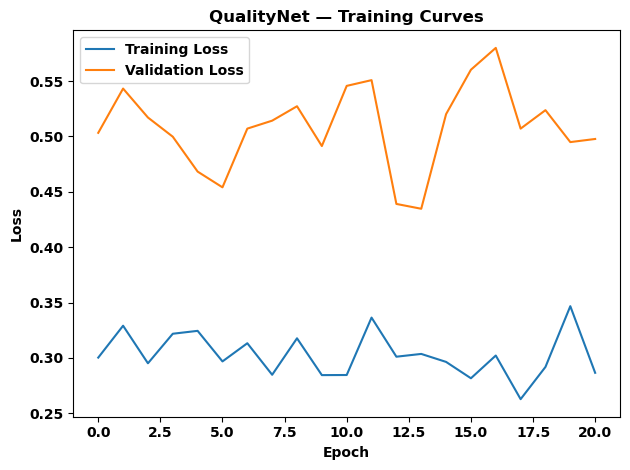

In [61]:
# ── Quality predictor: small NN on BERT question embeddings ─────────────────
class QualityNet(nn.Module):
    """Small binary classifier: predicts whether the QA model will answer correctly."""
    def __init__(self, input_dim=768):
        super(QualityNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, 1)    # single logit → sigmoid → P(correct)
        )

    def forward(self, x):
        return self.network(x).squeeze(1)


def train_quality_net(X_train_np, y_train_np, X_test_np, y_test_np,
                      num_epochs=30, lr=0.001, patience=5):

    X_tr = torch.tensor(X_train_np, dtype=torch.float32)
    y_tr = torch.tensor(y_train_np, dtype=torch.float32)
    X_te = torch.tensor(X_test_np,  dtype=torch.float32)
    y_te = torch.tensor(y_test_np,  dtype=torch.float32)

    loader_tr = DataLoader(TensorDataset(X_tr, y_tr), batch_size=64, shuffle=True)

    # Handle class imbalance via pos_weight
    n_pos      = y_tr.sum().item()
    n_neg      = len(y_tr) - n_pos
    pos_weight = torch.tensor([n_neg / max(n_pos, 1)])
    loss_fn    = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    model     = QualityNet().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_loss, best_state, pat_ctr = float("inf"), None, 0
    train_losses_q, test_losses_q  = [], []

    for epoch in range(num_epochs):
        model.train()
        epoch_losses = []
        for xb, yb in loader_tr:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_te.to(DEVICE)), y_te.to(DEVICE)).item()

        train_losses_q.append(np.mean(epoch_losses))
        test_losses_q.append(val_loss)

        if val_loss < best_loss:
            best_loss  = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            pat_ctr    = 0
        else:
            pat_ctr += 1
            if pat_ctr >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    return model, train_losses_q, test_losses_q


set_all_seeds()
qnet, ql_tr, ql_te = train_quality_net(X_bert_tr, y_q_tr, X_bert_te, y_q_te,
                                        num_epochs=50, lr=0.0005, patience=7)

training_curves(ql_tr, ql_te, title="QualityNet — Training Curves")

In [62]:
# ── Evaluate QualityNet ──────────────────────────────────────────────────────
qnet.eval()
with torch.no_grad():
    logits    = qnet(torch.tensor(X_bert_te, dtype=torch.float32).to(DEVICE)).cpu()
    probs     = torch.sigmoid(logits).numpy()
    y_hat_qn  = (probs >= 0.5).astype(int)

qn_acc = accuracy_score(y_q_te, y_hat_qn)
qn_auc = roc_auc_score(y_q_te, probs)
print(f"QualityNet (BERT question embeddings): Acc={qn_acc:.4f}  AUC={qn_auc:.4f}")

# ── Comparison table ─────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print(f"{'Quality Predictor':<35} {'Accuracy':>10} {'AUC':>8}")
print("-" * 55)
print(f"{'Logistic Reg. (hand features)':<35} {lr_acc:>10.4f} {lr_auc:>8.4f}")
print(f"{'QualityNet (BERT question emb.)':<35} {qn_acc:>10.4f} {qn_auc:>8.4f}")
print("=" * 55)
print("Baseline (predict always correct):",
      f"{y_q_te.mean():.4f}  —")

QualityNet (BERT question embeddings): Acc=0.6080  AUC=0.5363

Quality Predictor                     Accuracy      AUC
-------------------------------------------------------
Logistic Reg. (hand features)           0.4740   0.4582
QualityNet (BERT question emb.)         0.6080   0.5363
Baseline (predict always correct): 0.3820  —


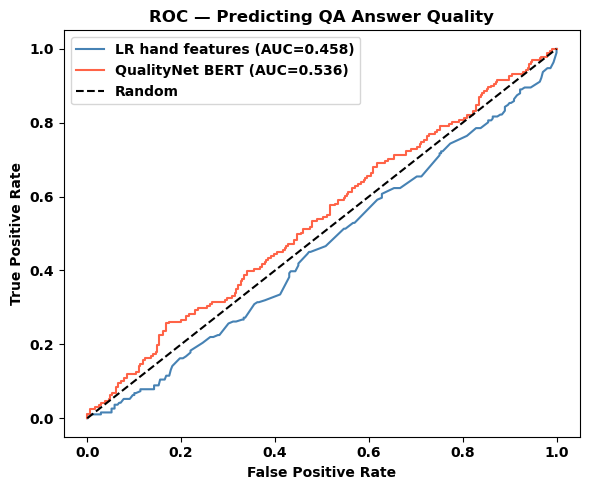

In [63]:
# ── ROC curves for both quality predictors ──────────────────────────────────
from sklearn.metrics import roc_curve

lr_probs = lr_pipe.predict_proba(X_hand_te)[:, 1]
fpr_lr,  tpr_lr,  _ = roc_curve(y_q_te, lr_probs)
fpr_qn,  tpr_qn,  _ = roc_curve(y_q_te, probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr_lr, tpr_lr, label=f"LR hand features (AUC={lr_auc:.3f})", color="steelblue")
plt.plot(fpr_qn, tpr_qn, label=f"QualityNet BERT (AUC={qn_auc:.3f})",  color="tomato")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Predicting QA Answer Quality")
plt.legend()
plt.tight_layout()
plt.show()

---
## Final Summary — All Variants and Axes

In [64]:
print("=" * 82)
print(f"{'Experiment':<50} {'Accuracy':>10} {'Macro-F1':>10} {'Macro-Prec':>10}")
print("-" * 82)

# Axis 1 – Text representation
print("  AXIS 1: Text Representation")
for name, acc, f1, pre in [
    ("  Variant A — [CLS] plain",          acc_a,     f1_a,     pre_a),
    ("  Variant B — [CLS] + MeSH",         acc_b,     f1_b,     pre_b),
    ("  Variant C — Mean-pool plain",       acc_c,     f1_c,     pre_c),
]:
    print(f"{name:<50} {acc:>10.4f} {f1:>10.4f} {pre:>10.4f}")

print("-" * 82)
# Axis 2 – MLP architecture
print("  AXIS 2: MLP Architecture")
for name, acc, f1, pre in [
    ("  Arch-1 — Baseline MLP",            acc_a,     f1_a,     pre_a),
    ("  Arch-2 — Deeper + BatchNorm",       acc_arch2, f1_arch2, pre_arch2),
    ("  Arch-3 — Residual MLP",             acc_arch3, f1_arch3, pre_arch3),
]:
    print(f"{name:<50} {acc:>10.4f} {f1:>10.4f} {pre:>10.4f}")

print("-" * 82)
print("  BEST MODEL (class weighting + early stopping)")
print(f"  {'Best Model':<48} {acc_best:>10.4f} {f1_best:>10.4f} {pre_best:>10.4f}")
print("=" * 82)

Experiment                                           Accuracy   Macro-F1 Macro-Prec
----------------------------------------------------------------------------------
  AXIS 1: Text Representation
  Variant A — [CLS] plain                              0.4260     0.3856     0.4209
  Variant B — [CLS] + MeSH                             0.4460     0.3906     0.3956
  Variant C — Mean-pool plain                          0.5720     0.3961     0.4104
----------------------------------------------------------------------------------
  AXIS 2: MLP Architecture
  Arch-1 — Baseline MLP                                0.4260     0.3856     0.4209
  Arch-2 — Deeper + BatchNorm                          0.5700     0.3861     0.3649
  Arch-3 — Residual MLP                                0.5520     0.2371     0.1840
----------------------------------------------------------------------------------
  BEST MODEL (class weighting + early stopping)
  Best Model                                           0.3